Dataset shape: (150, 4)

Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Cross Validation Scores: [0.96666667 1.         0.93333333 0.9        1.        ]
Average CV Score: 0.9600000000000002

PCA Shape: (150, 2)

Cluster Labels: [1 1 1 1 1 1 1 1 1 1]


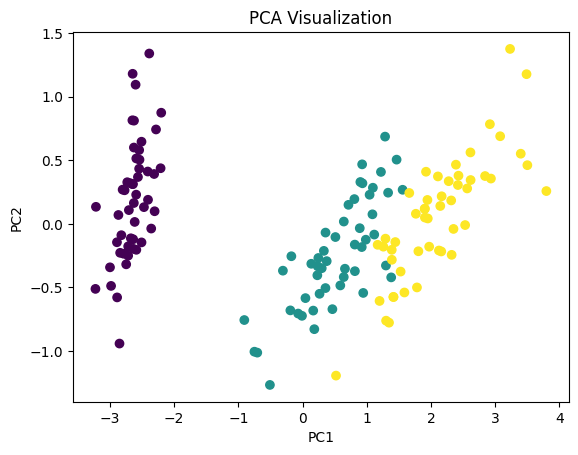


Model saved as iris_model.pkl


In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import joblib


iris = load_iris()
X = iris.data
y = iris.target

print("Dataset shape:", X.shape)



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=200))
])



pipeline.fit(X_train, y_train)


pred = pipeline.predict(X_test)



print("\nAccuracy:", accuracy_score(y_test, pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))



scores = cross_val_score(pipeline, X, y, cv=5)
print("\nCross Validation Scores:", scores)
print("Average CV Score:", scores.mean())



pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

print("\nPCA Shape:", X_reduced.shape)


kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

print("\nCluster Labels:", clusters[:10])



plt.scatter(X_reduced[:,0], X_reduced[:,1], c=y)
plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()



joblib.dump(pipeline, "iris_model.pkl")

print("\nModel saved as iris_model.pkl")